# TruckDrive Long-Range Failure Demo (FiftyOne) — Real Data

**The story:** TruckDrive ([CVPR 2026](https://torc-ai.github.io/TruckDrive/)) shows that state-of-the-art
autonomous-driving perception models *do not generalize beyond ~150 m*, with reported drops of
**31%-99%** in 3D perception tasks. Highway trucks need reliable scene understanding hundreds of
meters ahead because of long braking distances, so this "long-range gap" is a safety problem.

This notebook tells that story **on real TruckDrive data** — no synthetic stand-in. It:

1. Downloads a real scene with the official `download_truckdrive.sh` (cached; never re-downloads).
2. Loads the scene's real per-frame 3D annotations into FiftyOne, tagging every object with its
   `distance_from_ego` (computed from the 3D box center in the `velodyne` frame).
3. Attaches model predictions and runs detection evaluation.
4. Reports **recall as a function of distance band** — the long-range gap — and builds App views that
   jump straight to the long-range misses.

> **Requirements (all must hold, or the notebook stops with a clear error):**
> - FiftyOne 1.17 in the `fiftyone-workspace-plugin` venv (selected as the kernel).
> - You accept the **Torc Robotics Non-Commercial License v1.0** (`I_ACCEPT_LICENSE = True`).
> - `bash >= 4` and `curl` available (macOS ships bash 3.2 — `brew install bash`).
> - Network access to the TruckDrive distribution bucket.

To register the kernel:
```bash
python -m ipykernel install --user --name fiftyone-workspace-plugin \
    --display-name "Python (fiftyone-workspace-plugin)"
```

In [1]:
import sys
import fiftyone as fo

print("Python executable:", sys.executable)
print("FiftyOne version :", fo.__version__)

if "fiftyone-workspace-plugin" not in sys.executable:
    print(
        "\n[warning] This kernel does not appear to be the "
        "'fiftyone-workspace-plugin' venv. Select the right kernel if imports fail."
    )

Python executable: /Users/jimmyguerrero/fiftyone-workspace-plugin/.venv/bin/python
FiftyOne version : 1.17.0


## 1. Configuration

Pick the scene and the modalities to download. For the 2D long-range demo we only need
`annotations` (the 3D boxes) and `camera` (images). Add `"lidar"` if you later want point clouds.
TruckDrive data is under the **Torc Robotics Non-Commercial License v1.0** — set
`I_ACCEPT_LICENSE = True` to proceed.

In [2]:
import os

I_ACCEPT_LICENSE = True                 # <-- set True to accept the license and download
SCENE = "scene_28_1"                      # scene used in the official script's examples
MODALITIES = ["annotations", "camera", "lidar", "calibrations"]  # + calib for the projection overlay
PRIMARY_CAM = "forward_center_medium"   # camera folder under leopard/<cam>/images
LIDAR_MAX_POINTS = 120000                 # subsample cap per frame for snappy 3D rendering

MAX_RANGE = 400.0  # meters; TruckDrive's 3D annotation horizon
BANDS = ["00-075m", "075-150m", "150-250m", "250-400m"]

SCRIPT_URL = "https://d3ehgyu1hepsur.cloudfront.net/download_truckdrive.sh"
WORK_DIR = os.path.join(os.getcwd(), "truckdrive_demo_data")
DOWNLOAD_DIR = os.path.join(WORK_DIR, "TruckDrive_download")
SCRIPT_PATH = os.path.join(WORK_DIR, "download_truckdrive.sh")
SCENE_DIR = os.path.join(DOWNLOAD_DIR, "TruckDrive", SCENE)
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

DATASET_NAME = "truckdrive"


def distance_band(dist):
    if dist < 75:
        return "00-075m"
    if dist < 150:
        return "075-150m"
    if dist < 250:
        return "150-250m"
    return "250-400m"


print("Scene dir (after download):", SCENE_DIR)

Scene dir (after download): /Users/jimmyguerrero/Downloads/truckdrive_demo_data/TruckDrive_download/TruckDrive/scene_28_1


## 2. Download the scene (cached)

Drives the official `download_truckdrive.sh`. Two layers of caching mean re-runs don't re-download:
the notebook skips the whole step when the scene's modality folders are already populated, and the
script itself prints `[skip]` for any file already on disk. There is **no synthetic fallback** — if
the download can't run, the cell raises so you can fix the cause.

In [3]:
import glob
import shutil
import zipfile
import subprocess
import urllib.request


def _has_content(*paths):
    """True if any path is a non-empty directory, an existing file, or a glob
    pattern (containing '*') that matches at least one file."""
    for p in paths:
        if "*" in p:
            if glob.glob(p):
                return True
        elif os.path.isdir(p) and any(os.scandir(p)):
            return True
        elif os.path.isfile(p):
            return True
    return False


def scene_already_present(scene_dir, modalities):
    """True if the unzipped scene already has the content we need (no re-download).

    The zips extract FLAT into the scene dir: annotations.zip -> bounding_boxes/
    + lane_lines/ (no 'annotations/' parent), camera.zip -> leopard/<cam>/images/
    (no 'camera/' parent). lidar.zip is expected to extract to aeva/ + ouster/
    (also possibly under a lidar/ parent), so we accept either.
    """
    j = os.path.join
    checks = {
        "annotations": [j(scene_dir, "bounding_boxes")],
        "camera": [j(scene_dir, "leopard")],
        "lidar": [j(scene_dir, "aeva"), j(scene_dir, "ouster"),
                   j(scene_dir, "lidar")],
        "radar": [j(scene_dir, "conti542"), j(scene_dir, "radar")],
        "poses": [j(scene_dir, "poses")],
        "calibrations": [j(scene_dir, "calibrations"),
                          j(scene_dir, "calib*.json"),
                          j(scene_dir, "*calib*")],
    }
    for m in modalities:
        paths = checks.get(m, [os.path.join(scene_dir, m)])
        if not _has_content(*paths):
            return False
    return True


def _find_modern_bash():
    """Return a bash >= 4. macOS ships bash 3.2 at /bin/bash, which lacks
    `declare -A` (associative arrays) that download_truckdrive.sh requires."""
    candidates = [
        shutil.which("bash"),
        "/opt/homebrew/bin/bash",   # Homebrew, Apple Silicon
        "/usr/local/bin/bash",      # Homebrew, Intel
    ]
    for b in candidates:
        if not b or not os.path.exists(b):
            continue
        try:
            out = subprocess.run([b, "-c", "echo ${BASH_VERSINFO[0]}"],
                                 capture_output=True, text=True, check=True)
            if int(out.stdout.strip() or 0) >= 4:
                return b
        except Exception:
            continue
    return None


def fetch_official_script(url, dest):
    if os.path.exists(dest):
        print("[skip] download script already present")
        return
    urllib.request.urlretrieve(url, dest)
    os.chmod(dest, 0o755)
    print("Fetched", os.path.basename(dest))


def run_official_download(scene, modalities, out_dir, script_path):
    """Invoke download_truckdrive.sh for one scene + modalities using a bash >= 4.
    The script skips files already on disk, so this is safe to re-run."""
    bash = _find_modern_bash()
    if bash is None:
        raise RuntimeError(
            "Need bash >= 4 (macOS ships 3.2, which lacks `declare -A`). "
            "Install it with `brew install bash`."
        )
    mod_flags = [f"--{m}" for m in modalities]
    cmd = [bash, script_path, "--out", out_dir, "--scene", scene, "--yes",
           "--downloader", "curl", *mod_flags]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)


def unzip_modalities(scene_dir, modalities):
    """Unzip each <scene>/<modality>.zip in place (skip if already extracted).

    Note the zips extract flat: annotations.zip -> bounding_boxes/ + lane_lines/,
    camera.zip -> leopard/. The skip-marker maps each modality to its real folder.
    """
    markers = {"annotations": ["bounding_boxes"], "camera": ["leopard"],
               "lidar": ["aeva", "ouster", "lidar"], "radar": ["conti542", "radar"],
               "calibrations": ["calibrations", "calib*.json", "*calib*"]}
    for m in modalities:
        zpath = os.path.join(scene_dir, f"{m}.zip")
        marker_paths = [os.path.join(scene_dir, x) for x in markers.get(m, [m])]
        if _has_content(*marker_paths):
            print(f"[skip] {m} already extracted")
            continue
        if not os.path.exists(zpath):
            print(f"[warn] {zpath} not found; skipping")
            continue
        with zipfile.ZipFile(zpath) as zf:
            zf.extractall(scene_dir)
        print(f"Extracted {m}.zip")


print("Download helpers ready.")

Download helpers ready.


In [4]:
if scene_already_present(SCENE_DIR, MODALITIES):
    print(f"[cache] {SCENE} already downloaded & extracted -> skipping download.")
else:
    if not I_ACCEPT_LICENSE:
        raise RuntimeError(
            "I_ACCEPT_LICENSE is False. This notebook runs on real TruckDrive data only. "
            "Read the Torc Robotics Non-Commercial License v1.0 and set I_ACCEPT_LICENSE = True "
            "to download."
        )
    if _find_modern_bash() is None or shutil.which("curl") is None:
        raise RuntimeError(
            "bash >= 4 and curl are required to run the official downloader. "
            "On macOS: `brew install bash` (3.2 ships by default)."
        )
    fetch_official_script(SCRIPT_URL, SCRIPT_PATH)
    run_official_download(SCENE, MODALITIES, DOWNLOAD_DIR, SCRIPT_PATH)
    unzip_modalities(SCENE_DIR, MODALITIES)

# Hard requirement: the scene content must exist now. No fallback.
if not scene_already_present(SCENE_DIR, MODALITIES):
    raise RuntimeError(
        f"Expected scene content not found under {SCENE_DIR} after download. "
        f"Check the download output above, the SCENE name, and the bucket access."
    )
print("Scene is present at", SCENE_DIR)

[cache] scene_28_1 already downloaded & extracted -> skipping download.
Scene is present at /Users/jimmyguerrero/Downloads/truckdrive_demo_data/TruckDrive_download/TruckDrive/scene_28_1


## 3. Load the real scene into FiftyOne

Per the [dataset-viewer README](https://github.com/torc-ai/TruckDrive/blob/main/dataset_viewer/README.md),
an unzipped scene has 3D boxes at `bounding_boxes/<sync_id>_<ts>.json` (in the `velodyne`
frame) and images at `leopard/<cam>/images/<sync_id>_<ts>.jpg`. Images and annotations are
matched by **sync_id** (the first filename token), not exact timestamp. `distance_from_ego` is
`sqrt(x^2 + y^2)` from each box center.

The exact key names inside each box JSON aren't formally published, so `_parse_box` accepts the
common spellings. **If a real file uses different names, the loader prints a diagnostic showing the
keys it actually saw** so you can extend that one function.

In [5]:
import json
import numpy as np
from PIL import Image
from fiftyone import Sample, Detection, Detections


def _sync_id(path):
    """'<sync_id>_<timestamp>.<ext>' -> sync_id (first underscore token)."""
    return os.path.basename(path).split("_")[0]


def _parse_box(b):
    """Tolerant extraction of (center_xyz, dims, yaw, label, num_pts, bbox_2d).

    Accepts common key spellings. Returns None if no 3D center can be found.
    """
    center = None
    for k in ("center", "translation", "position", "xyz", "location", "center_3d"):
        v = b.get(k)
        if isinstance(v, (list, tuple)) and len(v) >= 3:
            center = v[:3]; break
    if center is None:
        if b.get("x") is not None and b.get("y") is not None:
            center = [b["x"], b["y"], b.get("z", 0.0)]
        else:
            return None
    dims = None
    for k in ("size", "dimensions", "dims", "extent", "wlh", "lwh", "size_3d"):
        v = b.get(k)
        if isinstance(v, (list, tuple)) and len(v) >= 3:
            dims = list(v[:3]); break
    if dims is None:
        dims = [b.get("l", b.get("length", 1.0)),
                b.get("w", b.get("width", 1.0)),
                b.get("h", b.get("height", 1.0))]
    yaw = b.get("yaw", b.get("heading", b.get("rotation_z", b.get("rot_z", 0.0))))
    label = b.get("label", b.get("category", b.get("class", b.get("type", "object"))))
    npts = b.get("num_lidar_points", b.get("num_lidar_pts", b.get("num_points")))
    bb2d = b.get("bbox_2d") or b.get("bbox")
    return ([float(c) for c in center], [float(d) for d in dims],
            float(yaw), str(label), npts, bb2d)


def _boxes_from_ann(ann_json):
    """Pull the list of box dicts out of an annotation file (a few container shapes)."""
    if isinstance(ann_json, list):
        return ann_json
    for k in ("boxes", "bounding_boxes", "objects", "annotations", "labels", "instances"):
        v = ann_json.get(k)
        if isinstance(v, list):
            return v
    return []


def _image_size(path):
    try:
        with Image.open(path) as im:
            return im.size  # (w, h)
    except Exception:
        return (1920, 1200)


def load_truckdrive_scene(scene_dir, primary_cam):
    # Real layout: annotations.zip extracts to <scene>/bounding_boxes/ (no
    # 'annotations/' parent); camera.zip extracts to <scene>/leopard/<cam>/images/.
    ann_dir = os.path.join(scene_dir, "bounding_boxes")
    ann_files = sorted(glob.glob(os.path.join(ann_dir, "*.json")))
    if not ann_files:
        raise RuntimeError(f"No bounding-box annotations under {ann_dir}")

    cam_glob = os.path.join(scene_dir, "leopard", primary_cam, "images", "*.jpg")
    images = glob.glob(cam_glob)
    if not images:  # fall back to any camera present
        images = glob.glob(os.path.join(scene_dir, "leopard", "**", "*.jpg"), recursive=True)
    if not images:
        raise RuntimeError(f"No camera images found under {scene_dir}/leopard")
    img_by_sid = {}
    for p in images:
        img_by_sid.setdefault(_sync_id(p), p)

    fo_samples, n_missing_img, n_boxes, sample_keys = [], 0, 0, None
    for ap in ann_files:
        sid = _sync_id(ap)
        img = img_by_sid.get(sid)
        if img is None:
            n_missing_img += 1
            continue
        iw, ih = _image_size(img)
        with open(ap) as f:
            ann = json.load(f)
        raw_boxes = _boxes_from_ann(ann)
        if sample_keys is None and raw_boxes and isinstance(raw_boxes[0], dict):
            sample_keys = sorted(raw_boxes[0].keys())

        gt = []
        for b in raw_boxes:
            if not isinstance(b, dict):
                continue
            parsed = _parse_box(b)
            if parsed is None:
                continue
            center, dims, yaw, label, npts, bb2d = parsed
            dist = float(np.sqrt(center[0] ** 2 + center[1] ** 2))  # range from ego, velodyne frame
            if isinstance(bb2d, (list, tuple)) and len(bb2d) == 4:
                x0, y0, x1, y1 = bb2d
                box = [x0 / iw, y0 / ih, (x1 - x0) / iw, (y1 - y0) / ih]
            else:
                # display-only marker; scaled by range so far objects look small.
                # (Tight 2D boxes require projecting the 3D box via the camera calib.)
                s = float(np.clip(12.0 / max(dist, 8.0), 0.006, 0.2))
                box = [0.5 - s / 2, 0.46 - s / 2, s, s]
            det = Detection(label=label, bounding_box=box,
                            distance_from_ego=round(dist, 1),
                            distance_band=distance_band(dist))
            if npts is not None:
                det["num_lidar_pts"] = int(npts)
            gt.append(det)
            n_boxes += 1

        s = Sample(filepath=img)
        s["ground_truth"] = Detections(detections=gt)
        s["sync_id"] = sid
        s["scene"] = os.path.basename(scene_dir.rstrip("/"))
        fo_samples.append(s)

    if n_missing_img:
        print(f"[note] {n_missing_img} annotation frames had no matching {primary_cam} image (skipped).")
    if n_boxes == 0:
        raise RuntimeError(
            "Parsed 0 boxes from the real annotations. The JSON schema differs from "
            f"what _parse_box expects.\nKeys seen on a sample box: {sample_keys}\n"
            "Extend _parse_box / _boxes_from_ann to match these keys."
        )
    print(f"Loaded {len(fo_samples)} frames, {n_boxes} boxes.")
    print(f"Box keys seen (first frame): {sample_keys}")
    return fo_samples


real_samples = load_truckdrive_scene(SCENE_DIR, PRIMARY_CAM)

Loaded 200 frames, 13733 boxes.
Box keys seen (first frame): ['Parent_id', 'Tracking_ID', 'acc_x', 'acc_x_ego', 'acc_y', 'acc_y_ego', 'acc_z', 'acc_z_ego', 'class-id', 'forward_right_wide', 'global2velodyne', 'h', 'h_ego', 'h_global', 'hardLabel_3d', 'id', 'interpolated', 'l', 'l_ego', 'l_global', 'length', 'pitch_rad', 'pos_x', 'pos_y', 'pos_z', 'roll_rad', 'sideward_right_front_wide', 'vel_x', 'vel_x_ego', 'vel_y', 'vel_y_ego', 'vel_z', 'vel_z_ego', 'velodyne2global', 'w', 'w_ego', 'w_global', 'width', 'x', 'x_ego', 'x_global', 'y', 'y_ego', 'y_global', 'yaw', 'yaw_ego', 'yaw_global', 'yaw_rad', 'z', 'z_ego', 'z_global']


In [6]:
if DATASET_NAME in fo.list_datasets():
    fo.delete_dataset(DATASET_NAME)

dataset = fo.Dataset(DATASET_NAME)
dataset.add_samples(real_samples)
dataset.persistent = True
dataset.add_dynamic_sample_fields()  # surface per-object distance attrs in the App sidebar

print(dataset)
print("\nGround-truth objects per distance band:")
from fiftyone import ViewField as F
for band in BANDS:
    n = dataset.filter_labels("ground_truth", F("distance_band") == band,
                              only_matches=False).count("ground_truth.detections")
    print(f"  {band}: {n}")

print("\nClasses present:", dataset.distinct("ground_truth.detections.label"))

 100% |█████████████████| 200/200 [1.5s elapsed, 0s remaining, 134.9 samples/s]         
Name:        truckdrive
Media type:  image
Num samples: 200
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    sync_id:          fiftyone.core.fields.StringField
    scene:            fiftyone.core.fields.StringField

Ground-truth objects per distance band:
  00-075m: 3514
  075-150m: 1960
  150-250m: 2113
  250-400m: 6146

Classes present: ['object']


## 4. Attach predictions and evaluate

Populate `predictions` by running your detector over each frame. Below is a clearly-marked
**placeholder** that derives range-degrading predictions from the ground truth so the evaluation path
runs on the real frames; **replace `predict_frame` with your real model** (e.g. an MMDetection3D model
from the devkit's `mmdet_project`) and everything downstream is unchanged.

In [7]:
import random

random.seed(7)
np.random.seed(7)


def _detection_probability(dist):
    """Placeholder detector behavior: ~0.97 up close, collapsing past ~150 m."""
    return float(np.clip(1.0 / (1.0 + np.exp((dist - 150.0) / 35.0)), 0.02, 0.98))


def _perturb(box, dist):
    noise = 0.004 + 0.06 * (dist / MAX_RANGE)
    x, y, w, h = box
    x += np.random.uniform(-noise, noise)
    y += np.random.uniform(-noise, noise)
    w *= np.random.uniform(1.0 - noise * 4, 1.0 + noise * 4)
    h *= np.random.uniform(1.0 - noise * 4, 1.0 + noise * 4)
    return [float(x), float(y), float(max(w, 0.004)), float(max(h, 0.004))]


def predict_frame(gt_detections):
    """PLACEHOLDER. Replace with your model's detections for this frame.
    Must return a list of fo.Detection with a `confidence` (and ideally the
    distance attrs copied through so predictions are sliceable too)."""
    preds = []
    for det in gt_detections:
        dist = det["distance_from_ego"]
        if random.random() < _detection_probability(dist):
            conf = float(np.clip(1.0 - dist / (MAX_RANGE * 1.1) + np.random.uniform(-0.1, 0.1), 0.05, 0.99))
            preds.append(Detection(
                label=det.label,
                bounding_box=_perturb(list(det.bounding_box), dist),
                confidence=round(conf, 3),
                distance_from_ego=dist,
                distance_band=det["distance_band"],
            ))
    return preds


for s in dataset:
    s["predictions"] = Detections(detections=predict_frame(s["ground_truth"].detections))
    s.save()

results = dataset.evaluate_detections(
    "predictions", gt_field="ground_truth", eval_key="eval", compute_mAP=True,
)
print(f"Overall mAP: {results.mAP():.3f}")

Evaluating detections...
 100% |█████████████████| 200/200 [23.8s elapsed, 0s remaining, 18.6 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 200/200 [13.0s elapsed, 0s remaining, 27.2 samples/s]      
Overall mAP: 0.260


## 5. The headline: accuracy vs. distance
Recall per distance band = fraction of GT objects in that band the model matched. The long-range gap
is the drop past 150 m.

In [8]:
def recall_by_band(dset, gt_field="ground_truth"):
    rows = []
    for band in BANDS:
        gt_in_band = dset.filter_labels(
            gt_field, F("distance_band") == band, only_matches=False
        ).count(f"{gt_field}.detections")
        gt_matched = dset.filter_labels(
            gt_field, (F("distance_band") == band) & (F("eval") == "tp"),
            only_matches=False,
        ).count(f"{gt_field}.detections")
        recall = (gt_matched / gt_in_band) if gt_in_band else float("nan")
        rows.append((band, gt_in_band, gt_matched, recall))
    return rows


def print_band_table(rows):
    print(f"{'band':>10} {'#gt':>6} {'#found':>7} {'recall':>8}")
    print("-" * 35)
    for band, n_gt, n_found, rec in rows:
        rec_s = f"{rec:>7.1%}" if n_gt else "     n/a"
        print(f"{band:>10} {n_gt:>6} {n_found:>7} {rec_s}")
    valid = [r for r in rows if r[1]]
    if len(valid) >= 2 and valid[0][3]:
        near, far = valid[0][3], valid[-1][3]
        print(f"\nRecall drop {valid[0][0]} -> {valid[-1][0]}: {(1 - far / near):.0%}")


rows = recall_by_band(dataset)
print_band_table(rows)

      band    #gt  #found   recall
-----------------------------------
   00-075m   3514    3396   96.6%
  075-150m   1960    1427   72.8%
  150-250m   2113     126    6.0%
  250-400m   6146       0    0.0%

Recall drop 00-075m -> 250-400m: 100%


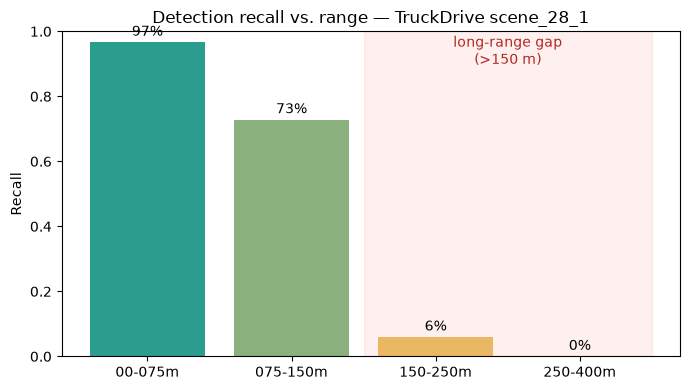

In [9]:
import matplotlib.pyplot as plt

bands = [r[0] for r in rows]
recalls = [r[3] for r in rows]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bands, recalls, color=["#2a9d8f", "#8ab17d", "#e9c46a", "#e76f51"])
ax.axvspan(1.5, 3.5, color="red", alpha=0.06)
ax.text(2.5, 0.9, "long-range gap\n(>150 m)", ha="center", color="#b3261e", fontsize=10)
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.0)
ax.set_title(f"Detection recall vs. range — TruckDrive {SCENE}")
for i, r in enumerate(recalls):
    if r == r:  # not NaN
        ax.text(i, r + 0.02, f"{r:.0%}", ha="center")
plt.tight_layout()
plt.show()

## 6. Distance-sliced views + App
Saved views jump straight to the long-range misses. In the App, open the **Model Evaluation** panel
and filter `ground_truth`/`predictions` by `distance_from_ego` or `distance_band` in the sidebar.

In [10]:
long_range_misses = dataset.filter_labels(
    "ground_truth", (F("distance_from_ego") > 150.0) & (F("eval") == "fn"),
)
near_field = dataset.filter_labels("ground_truth", F("distance_from_ego") < 75.0)

for name, view in [("long_range_misses", long_range_misses),
                   ("near_field_sanity", near_field)]:
    dataset.save_view(name, view, overwrite=True)
    print(f"saved view '{name}': {len(view)} samples")

print("\nLong-range missed objects:", long_range_misses.count("ground_truth.detections"))

saved view 'long_range_misses': 200 samples
saved view 'near_field_sanity': 200 samples

Long-range missed objects: 8132


Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port



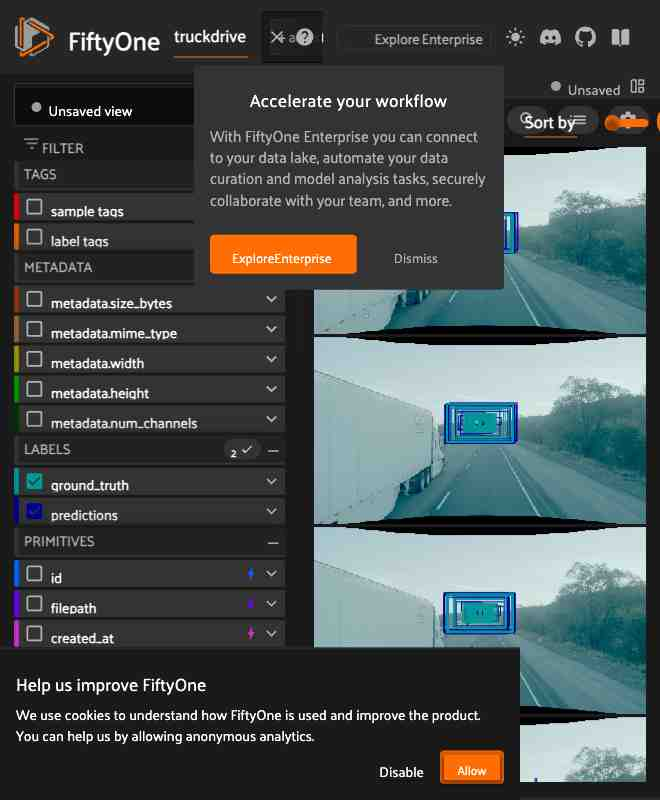

Dataset:          truckdrive
Media type:       image
Num samples:      200
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/

In [11]:
session = fo.launch_app(dataset)
# session.view = long_range_misses  # open directly on the failures
session

### Notes

- **Caching:** the scene downloads once; re-runs skip it (folder check + the script's own `[skip]`).
  Delete the scene folder to force a refresh, or change `SCENE` for a different one.
- **2D boxes:** TruckDrive boxes are 3D in the `velodyne` frame. The loader draws a real 2D box only
  when the annotation includes a pixel `bbox`; otherwise it shows a range-scaled marker. For tight
  boxes on the image, project the 3D box using `calibrations/calib_camera_leopard_<camera>.json` +
  `calib_tf_tree_full.json`. The distance-band evaluation is unaffected — it uses the 3D centers.
- **Multimodal sections:** Sections 7-9 add the FMCW LiDAR (3D point clouds colored by range), a
  grouped camera+LiDAR dataset, and a projection overlay that paints LiDAR points on the image.
  The Aeva binaries also carry a per-point FMCW radial-velocity column, but its raw values are in
  the sensor frame (dominated by ego motion); turning it into clean moving-vs-static coloring needs
  ego-motion compensation matched to the dataset's exact velocity convention (see the devkit), so
  it's left out here and the demo shows only quantities derivable from point geometry.
- **Schema:** if box parsing fails, the loader raises with the exact keys it saw; extend `_parse_box`.

> **Licensing:** TruckDrive data is under the Torc Robotics Non-Commercial License v1.0 (the devkit
> and download script are Apache-2.0; the data is not). Commercial use requires a separate written
> agreement.

## 7. FMCW LiDAR point clouds

TruckDrive's distinctive sensor is its **long-range FMCW LiDAR** (AEVA Aeries II), which returns
points out to ~400 m. We load the Aeva point clouds for this scene, color each point by its
**distance from the ego vehicle**, and build a FiftyOne 3D scene per frame plus a bird's-eye
orthographic preview for the sample grid. Coloring by range makes the sensor's long reach visible:
near returns read warm, distant returns read cool.

The loader searches tolerantly for the `.bin` files (the lidar zip may extract to `aeva/...` flat,
or under a `lidar/` parent) and prints what it finds, so a layout surprise is visible rather than
silent. Each `.bin` is converted to a colored `.pcd` that FiftyOne renders natively.

> Note: the Aeva binaries also carry a per-point FMCW radial-velocity channel. Turning that raw
> value into clean moving-vs-static coloring requires ego-motion compensation tied to the dataset's
> exact velocity convention (see the devkit); it's intentionally left out here so the demo only
> shows quantities we can derive reliably from the point geometry.


In [12]:
import struct
import fiftyone.utils.utils3d as fou3d

LIDAR_SCENE_DIR = os.path.join(WORK_DIR, "lidar_scenes")  # .pcd + .fo3d outputs
os.makedirs(LIDAR_SCENE_DIR, exist_ok=True)


def _find_lidar_bins(scene_dir):
    """Locate Aeva joint-LiDAR .bin files regardless of flat/nested extraction."""
    patterns = [
        os.path.join(scene_dir, "aeva", "joint_lidars", "points", "*.bin"),
        os.path.join(scene_dir, "lidar", "aeva", "joint_lidars", "points", "*.bin"),
        os.path.join(scene_dir, "aeva", "**", "*.bin"),
        os.path.join(scene_dir, "**", "aeva", "**", "*.bin"),
    ]
    for pat in patterns:
        hits = glob.glob(pat, recursive=True)
        if hits:
            return sorted(hits)
    return []


def _range_to_rgb(rng_m, rmax=300.0):
    """Color by distance from ego: near = warm (red/orange), far = cool (blue).
    A simple perceptual ramp through red -> yellow -> green -> blue."""
    t = np.clip(rng_m / rmax, 0.0, 1.0)
    # 4-stop ramp
    r = np.clip(1.5 - 2.0 * t, 0, 1)
    g = np.clip(1.0 - np.abs(2.0 * t - 1.0), 0, 1)
    b = np.clip(2.0 * t - 0.5, 0, 1)
    return (np.clip(np.stack([r, g, b], 1), 0, 1) * 255).astype(np.uint8)


def _pack_rgb_f32(rgb):
    r = rgb[:, 0].astype(np.uint32); g = rgb[:, 1].astype(np.uint32); b = rgb[:, 2].astype(np.uint32)
    packed = (r << 16) | (g << 8) | b
    return packed.view(np.float32)


def bin_to_colored_pcd(bin_path, pcd_path, max_points=LIDAR_MAX_POINTS):
    pts = np.fromfile(bin_path, dtype=np.float64)
    if pts.size % 11 != 0:
        raise ValueError(f"{bin_path}: {pts.size} values not divisible by 11 cols")
    pts = pts.reshape(-1, 11)
    if len(pts) > max_points:
        idx = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts = pts[idx]
    xyz = pts[:, :3].astype(np.float32)
    rng_m = np.sqrt((xyz[:, :2] ** 2).sum(axis=1))   # ground-plane distance from ego
    rgb_f = _pack_rgb_f32(_range_to_rgb(rng_m))
    n = len(pts)
    header = (
        "# .PCD v0.7 - Point Cloud Data file format\n"
        "VERSION 0.7\nFIELDS x y z rgb\nSIZE 4 4 4 4\nTYPE F F F F\nCOUNT 1 1 1 1\n"
        f"WIDTH {n}\nHEIGHT 1\nVIEWPOINT 0 0 0 1 0 0 0\nPOINTS {n}\nDATA binary\n"
    )
    buf = np.zeros((n, 4), dtype=np.float32)
    buf[:, :3] = xyz; buf[:, 3] = rgb_f
    with open(pcd_path, "wb") as f:
        f.write(header.encode("ascii"))
        f.write(buf.tobytes())
    return n


bins = _find_lidar_bins(SCENE_DIR)
print(f"Found {len(bins)} Aeva LiDAR .bin frames.")
if bins:
    print("example:", os.path.relpath(bins[0], SCENE_DIR))

# Convert each .bin -> range-colored .pcd -> per-frame .fo3d scene.
lidar_samples = []
for bp in bins:
    sid = _sync_id(bp)
    pcd_path = os.path.join(LIDAR_SCENE_DIR, f"{sid}.pcd")
    fo3d_path = os.path.join(LIDAR_SCENE_DIR, f"{sid}.fo3d")
    try:
        npts = bin_to_colored_pcd(bp, pcd_path)
    except Exception as e:
        print(f"[skip] {os.path.basename(bp)}: {e}")
        continue
    pc = fo.PointCloud(f"aeva_{sid}", pcd_path, flag_for_projection=True)
    pc.default_material.shading_mode = "rgb"
    scene = fo.Scene()
    scene.add(pc)
    scene.write(fo3d_path)
    s = Sample(filepath=fo3d_path)
    s["sync_id"] = sid
    s["scene"] = SCENE
    s["n_points"] = npts
    lidar_samples.append(s)

print(f"Built {len(lidar_samples)} LiDAR scenes.")


Found 260 Aeva LiDAR .bin frames.
example: aeva/joint_lidars/points/0000_0.bin
Built 260 LiDAR scenes.


 100% |█████████████████| 260/260 [62.2ms elapsed, 0s remaining, 4.2K samples/s]   
   0% |/----------------|   0/260 [4.0ms elapsed, ? remaining, ? samples/s]   
[note] BEV projection skipped: PackageError("The requested operation requires that 'open3d' is installed on your machine.\n\nIf you think this error is inaccurate, you can set `fiftyone.config.requirement_error_level` to 1 (warning) or 2 (ignore).\nSee https://docs.voxel51.com/user_guide/config.html for details.")
Name:        truckdrive-lidar
Media type:  3d
Num samples: 260
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeFiel


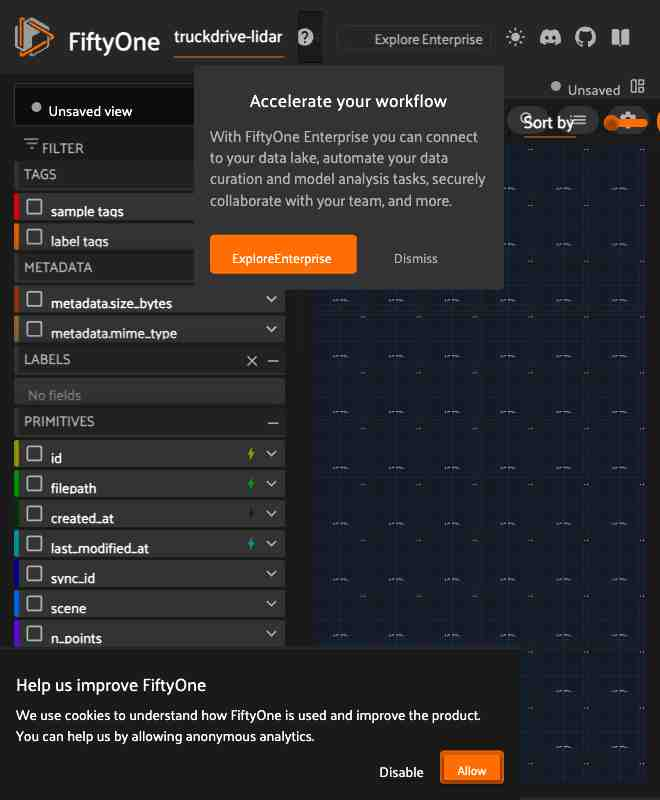

In [13]:
LIDAR_DATASET = "truckdrive-lidar"
if lidar_samples:
    if LIDAR_DATASET in fo.list_datasets():
        fo.delete_dataset(LIDAR_DATASET)
    lidar_ds = fo.Dataset(LIDAR_DATASET)
    lidar_ds.add_samples(lidar_samples)
    lidar_ds.persistent = True

    # Bird's-eye orthographic previews so the 3D frames are browsable in the grid.
    try:
        fou3d.compute_orthographic_projection_images(
            lidar_ds, (-1, 512), os.path.join(WORK_DIR, "lidar_bev")
        )
        print("Computed orthographic BEV previews.")
    except Exception as e:
        print("[note] BEV projection skipped:", repr(e))

    print(lidar_ds)
    lidar_session = fo.launch_app(lidar_ds)
    lidar_session
else:
    print("No LiDAR frames loaded -> check that 'lidar' is in MODALITIES and the zip extracted.")
    print("If the .bin files are under an unexpected path, extend _find_lidar_bins().")


## 8. Combined view: camera + LiDAR in one grouped dataset

A FiftyOne **grouped dataset** ties the camera image and the 3D point cloud for the *same frame* into
one group, joined by `sync_id`. In the App you get a slice selector to flip between the `image` slice
(camera, with the `ground_truth` detections) and the `pcd` slice (the velocity-colored 3D scene) for
the same moment, and the 3D panel can render alongside the image.

This reuses what we already built: `real_samples` (camera frames, Section 3) and `lidar_samples`
(velocity-colored `.fo3d` scenes, Section 7). Frames present in both are grouped; the join key is the
`sync_id` each sample already carries.

> Note: this gives image and cloud **side-by-side / switchable** for the same frame. Painting the
> LiDAR points *onto* the image pixels is the projection overlay in Section 9, which needs the
> calibration files.

In [14]:
GROUPED_DATASET = "truckdrive-grouped"

# Index the camera frames and LiDAR scenes by sync_id.
cam_by_sid = {s["sync_id"]: s for s in real_samples}
lid_by_sid = {s["sync_id"]: s for s in lidar_samples} if "lidar_samples" in dir() else {}

shared = sorted(set(cam_by_sid) & set(lid_by_sid))
print(f"camera frames: {len(cam_by_sid)}, lidar frames: {len(lid_by_sid)}, "
      f"frames in both: {len(shared)}")
if not shared:
    print("[warn] no overlapping sync_ids -> run Sections 3 and 7 first, "
          "and confirm both loaded frames.")

if GROUPED_DATASET in fo.list_datasets():
    fo.delete_dataset(GROUPED_DATASET)

grouped = fo.Dataset(GROUPED_DATASET)
grouped.add_group_field("group", default="image")

group_samples = []
for sid in shared:
    g = fo.Group()
    cam = cam_by_sid[sid]
    lid = lid_by_sid[sid]

    # image slice: carry over the camera frame + its ground-truth detections
    img_sample = fo.Sample(filepath=cam.filepath, group=g.element("image"))
    img_sample["ground_truth"] = cam["ground_truth"]
    img_sample["sync_id"] = sid
    img_sample["scene"] = SCENE

    # pcd slice: the velocity-colored 3D scene (.fo3d)
    pcd_sample = fo.Sample(filepath=lid.filepath, group=g.element("pcd"))
    pcd_sample["sync_id"] = sid
    pcd_sample["scene"] = SCENE
    pcd_sample["n_points"] = lid["n_points"]

    group_samples.extend([img_sample, pcd_sample])

if group_samples:
    grouped.add_samples(group_samples)
    grouped.persistent = True
    grouped.add_dynamic_sample_fields()
    print(grouped)
    print("\nslices:", grouped.group_slices, "| media types:", grouped.group_media_types)


camera frames: 200, lidar frames: 260, frames in both: 200
 100% |█████████████████| 400/400 [1.4s elapsed, 0s remaining, 286.9 samples/s]         
Name:        truckdrive-grouped
Media type:  group
Group slice: image
Num groups:  200
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    group:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.groups.Group)
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    sync_id:          fiftyone.core.fields.StringField
    scene:            fiftyone.core.fields.StringField
    

In [15]:
# Launch the grouped dataset. Use the slice selector (top of the grid) to switch
# between the 'image' and 'pcd' views of the same frame; open a sample to see the
# 3D panel alongside the image.
if "grouped" in dir() and len(grouped) > 0:
    grouped_session = fo.launch_app(grouped)
    grouped_session
else:
    print("Grouped dataset is empty - see the warning above.")


## 9. Projection overlay: LiDAR points painted on the image

This projects the LiDAR points (in the `velodyne` frame) into the primary camera and overlays them on
the image as keypoints **colored by distance from the ego vehicle** — so you see the sensor's depth
structure directly on the photo, not just in the 3D view.

It uses the `calibrations` modality: the camera intrinsic (`K`) from the ROS `CameraInfo`
`calib_camera_leopard_<cam>.json`, and the `velodyne -> camera` transform composed by chaining the
tf-tree edges in `calib_tf_tree_full.json` (velodyne -> cab -> camera). `_load_calibration` prints the
files and matrices it resolved; if it can't find them it explains what to adjust rather than failing
silently.

> If the overlay looks misaligned, the most likely cause is the extrinsic's frame convention;
> `_load_calibration` / `_transform_between` is where to correct it.


In [16]:
# Section 9 calibration loader: reads the real TruckDrive ROS-style calib schema.
#
#   calib_camera_leopard_<cam>.json : ROS CameraInfo
#       K = flat 9 (row-major 3x3 intrinsic), D = distortion, P = 3x4, image height/width
#   calib_tf_tree_full.json : flat dict of frame edges, each
#       <name>: {header:{frame_id: PARENT}, child_frame_id: CHILD,
#                transform:{translation:{x,y,z}, rotation:{x,y,z,w}}}
#
# The LiDAR points are in the `velodyne` frame; the camera is `camera_leopard_<cam>`.
# There is no direct edge, so we chain through the shared `cab` parent:
#   T_cam_velodyne = inv(T_parent<-cam) @ T_parent<-velodyne     (both parents = cab)
# More generally we find the path between the two frames in the edge graph.

CALIB_DIR_CANDIDATES = [
    os.path.join(SCENE_DIR, "calibrations"),
    os.path.join(SCENE_DIR, "calibration"),
    SCENE_DIR,
]


def _find_calib_files(scene_dir, primary_cam):
    cam_json, tree_json = None, None
    for base in CALIB_DIR_CANDIDATES:
        if not os.path.isdir(base):
            continue
        for p in glob.glob(os.path.join(base, "**", "*.json"), recursive=True):
            name = os.path.basename(p).lower()
            if "calib_camera" in name and primary_cam.lower() in name and cam_json is None:
                cam_json = p
            if "tf_tree" in name and tree_json is None:
                tree_json = p
    return cam_json, tree_json


def _quat_to_R(x, y, z, w):
    n = (x * x + y * y + z * z + w * w) ** 0.5
    if n == 0:
        return np.eye(3)
    x, y, z, w = x / n, y / n, z / n, w / n
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - z * w),     2 * (x * z + y * w)],
        [2 * (x * y + z * w),     1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
        [2 * (x * z - y * w),     2 * (y * z + x * w),     1 - 2 * (x * x + y * y)],
    ])


def _edge_to_T(edge):
    """ROS transform dict -> 4x4 matrix that maps CHILD-frame points into PARENT frame."""
    t = edge["transform"]["translation"]
    r = edge["transform"]["rotation"]
    T = np.eye(4)
    T[:3, :3] = _quat_to_R(r["x"], r["y"], r["z"], r["w"])
    T[:3, 3] = [t["x"], t["y"], t["z"]]
    return T


def _build_frame_graph(tree):
    """Return adjacency: frame -> list of (neighbor, 4x4 T mapping `frame` pts -> `neighbor`)."""
    graph = {}
    for edge in tree.values():
        if not isinstance(edge, dict) or "transform" not in edge:
            continue
        parent = edge.get("header", {}).get("frame_id")
        child = edge.get("child_frame_id")
        if parent is None or child is None:
            continue
        T_parent_child = _edge_to_T(edge)          # child pts -> parent
        T_child_parent = np.linalg.inv(T_parent_child)
        graph.setdefault(child, []).append((parent, T_parent_child))
        graph.setdefault(parent, []).append((child, T_child_parent))
    return graph


def _transform_between(tree, src_frame, dst_frame):
    """4x4 mapping points in src_frame -> dst_frame, by BFS over the tf graph."""
    graph = _build_frame_graph(tree)
    if src_frame not in graph or dst_frame not in graph:
        return None
    from collections import deque
    q = deque([(src_frame, np.eye(4))])
    seen = {src_frame}
    while q:
        frame, T_acc = q.popleft()             # T_acc: src pts -> frame
        if frame == dst_frame:
            return T_acc
        for nbr, T_fn in graph[frame]:          # T_fn: frame pts -> nbr
            if nbr not in seen:
                seen.add(nbr)
                q.append((nbr, T_fn @ T_acc))
    return None


def _load_calibration(scene_dir, primary_cam, lidar_frame="velodyne"):
    """Return (K 3x3, T 4x4 velodyne->camera, D distortion) or (None, None, None)."""
    cam_json, tree_json = _find_calib_files(scene_dir, primary_cam)
    print("camera calib:", cam_json)
    print("tf tree     :", tree_json)
    if cam_json is None or tree_json is None:
        print("[calib] missing camera JSON or tf tree -> cannot project.")
        return None, None, None

    cam = json.load(open(cam_json))
    K_flat = cam.get("K")
    if K_flat is None or len(K_flat) != 9:
        print("[calib] camera JSON has no flat-9 'K' intrinsic -> adjust loader.")
        return None, None, None
    K = np.array(K_flat, dtype=float).reshape(3, 3)
    D = np.array(cam.get("D", []), dtype=float)

    cam_frame = cam.get("header", {}).get("frame_id") or f"camera_leopard_{primary_cam}"
    tree = json.load(open(tree_json))
    T = _transform_between(tree, lidar_frame, cam_frame)   # velodyne pts -> camera frame
    if T is None:
        frames = sorted(set(
            [e.get("child_frame_id") for e in tree.values() if isinstance(e, dict)]
            + [e.get("header", {}).get("frame_id") for e in tree.values() if isinstance(e, dict)]
        ))
        print(f"[calib] no tf path {lidar_frame} -> {cam_frame}. Known frames: {frames}")
        return None, None, None
    return K, T, D


K, T, D = _load_calibration(SCENE_DIR, PRIMARY_CAM)
projection_ok = K is not None and T is not None
if projection_ok:
    print("\ncamera frame:", PRIMARY_CAM)
    print("Intrinsic K:\n", np.round(K, 2))
    print("Extrinsic T (velodyne->camera):\n", np.round(T, 4))
    if D is not None and len(D):
        print("Distortion D:", np.round(D, 4), "(not applied; points are near image center)")


def _project(xyz, T, K, img_w, img_h):
    homo = np.hstack([xyz, np.ones((len(xyz), 1))])
    cam = (T @ homo.T).T[:, :3]
    z = cam[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        u = (K @ cam.T).T[:, 0] / z
        v = (K @ cam.T).T[:, 1] / z
    valid = (z > 0.1) & (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
    return u, v, z, valid



camera calib: /Users/jimmyguerrero/Downloads/truckdrive_demo_data/TruckDrive_download/TruckDrive/scene_28_1/calib_camera_leopard_forward_center_medium.json
tf tree     : /Users/jimmyguerrero/Downloads/truckdrive_demo_data/TruckDrive_download/TruckDrive/scene_28_1/calib_tf_tree_full.json

camera frame: forward_center_medium
Intrinsic K:
 [[3.33431e+03 0.00000e+00 1.94836e+03]
 [0.00000e+00 3.33431e+03 1.06186e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]
Extrinsic T (velodyne->camera):
 [[ 0.021  -0.9998  0.0064 -0.09  ]
 [ 0.0129 -0.0061 -0.9999 -0.074 ]
 [ 0.9997  0.0211  0.0128 -3.0135]
 [ 0.      0.      0.      1.    ]]
Distortion D: [0. 0. 0. 0. 0.] (not applied; points are near image center)


In [ ]:
from fiftyone import Keypoint, Keypoints

OVERLAY_DATASET = "truckdrive-overlay"
OVERLAY_MAX_PTS = 1500   # keypoints per image to keep the App responsive

# Color projected points by distance from ego. Discrete range bands render cleanly
# in the App via a saved ColorScheme (no need to touch the color palette).
RANGE_BANDS = [
    ("00-075m", 0, 75, "#e8413a"),
    ("075-150m", 75, 150, "#e8a23a"),
    ("150-250m", 150, 250, "#3ac06b"),
    ("250m+", 250, 1e9, "#3a7be8"),
]


def _range_band(r):
    for name, lo, hi, _ in RANGE_BANDS:
        if lo <= r < hi:
            return name
    return RANGE_BANDS[-1][0]


if not projection_ok:
    print("Projection not available (see calib messages above) -> skipping overlay.")
elif not bins:
    print("No LiDAR bins -> skipping overlay.")
else:
    if OVERLAY_DATASET in fo.list_datasets():
        fo.delete_dataset(OVERLAY_DATASET)
    overlay_ds = fo.Dataset(OVERLAY_DATASET)

    cam_by_sid = {s["sync_id"]: s for s in real_samples}
    made = 0
    overlay_samples = []
    for bp in bins:
        sid = _sync_id(bp)
        cam = cam_by_sid.get(sid)
        if cam is None:
            continue
        with Image.open(cam.filepath) as im:
            iw, ih = im.size
        pts = np.fromfile(bp, dtype=np.float64)
        if pts.size % 11:
            continue
        pts = pts.reshape(-1, 11)
        xyz = pts[:, :3]
        u, v, z, valid = _project(xyz, T, K, iw, ih)
        ui, vi = u[valid], v[valid]
        xy_valid = xyz[valid]
        rng_valid = np.sqrt(xy_valid[:, 0] ** 2 + xy_valid[:, 1] ** 2)
        if len(ui) > OVERLAY_MAX_PTS:
            idx = np.random.default_rng(0).choice(len(ui), OVERLAY_MAX_PTS, replace=False)
            ui, vi, rng_valid = ui[idx], vi[idx], rng_valid[idx]
        # One Keypoint per point, labeled by range band (drives color) and carrying
        # the raw range as an inspectable attribute.
        kps = [
            Keypoint(
                label=_range_band(r),
                points=[[float(x / iw), float(y / ih)]],
                range_m=float(r),
            )
            for x, y, r in zip(ui, vi, rng_valid)
        ]
        # ground_truth is intentionally NOT copied: the 2D boxes are range-scaled
        # placeholders and clutter the projection view. (Tight boxes need 3D->2D box
        # projection.) The point of this dataset is the LiDAR overlay.
        s = fo.Sample(filepath=cam.filepath)
        s["lidar_proj"] = Keypoints(keypoints=kps)
        s["sync_id"] = sid
        s["scene"] = SCENE
        overlay_samples.append(s)
        made += 1

    if overlay_samples:
        overlay_ds.add_samples(overlay_samples)
        overlay_ds.persistent = True
        overlay_ds.add_dynamic_sample_fields()

        # Save a color scheme so the range bands render automatically on load.
        overlay_ds.app_config.color_scheme = fo.ColorScheme(
            color_by="value",
            color_pool=[c for *_, c in RANGE_BANDS],
            fields=[
                {
                    "path": "lidar_proj",
                    "colorByAttribute": "label",
                    "valueColors": [
                        {"value": name, "color": c} for name, _, _, c in RANGE_BANDS
                    ],
                }
            ],
            multicolor_keypoints=True,
        )
        overlay_ds.save()

        print(f"Built overlay dataset: {made} frames with range-colored LiDAR keypoints.")
        print("Colors load automatically by distance band: near=red ... far=blue.")
        overlay_session = fo.launch_app(overlay_ds)
        overlay_session
    else:
        print("No frames had both a calib-projected cloud and a matching image.")


  94% |███████████████/-| 188/200 [30.9s elapsed, 2.1s remaining, 5.6 samples/s]    

In [ ]:
# Cleanup (optional)
# session.close(); lidar_session.close(); grouped_session.close(); overlay_session.close()
# fo.delete_dataset(DATASET_NAME)
# fo.delete_dataset("truckdrive-lidar")
# fo.delete_dataset("truckdrive-grouped")
# fo.delete_dataset("truckdrive-overlay")